In [1]:
import torch
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForLanguageModeling

/home/jupyter-admin/.conda/envs/lora/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Configuration ---
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0" # A small, capable model for quick testing
dataset_name = "tatsu-lab/alpaca" # A standard instruction-following dataset

In [3]:
# --- Step 2: Load Model and Tokenizer ---
# We load the model in 4-bit precision to save memory, a common practice.
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    load_in_4bit=True,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token # Set pad token for batching

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


In [4]:
# --- Step 3: Configure OLoRA ---
# This is the most important step. We activate OLoRA by setting `init_lora_weights`.
# The `peft` library handles the QR decomposition internally when this is set.
olora_config = LoraConfig(
    r=32,  # The rank of the low-rank matrices. The paper tested 32 and 64. [1]
    lora_alpha=16, # The scaling factor. The paper used 16. [1]
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"], # Target the attention layers
    lora_dropout=0.05, # The paper used a dropout of 0.05. [1]
    bias="none",
    task_type="CAUSAL_LM",
    init_lora_weights="olora" # This is the key parameter to activate OLoRA initialization.
)

In [5]:
# --- Step 4: Apply PEFT to the Model ---
# This wraps the base model with the OLoRA adapter layers.
model = get_peft_model(model, olora_config)
model.print_trainable_parameters()

trainable params: 9,011,200 || all params: 1,109,059,584 || trainable%: 0.8125


In [6]:
#--- Step 5: Prepare the Dataset ---
#We'll format the Alpaca dataset for our instruction-tuning task.
# def formatting_prompts_func(example):
#     output_texts = []
#     for i in range(len(example['instruction'])):
#         text = f"### Instruction:\n{example['instruction'][i]}\n\n### Response:\n{example['output'][i]}"
#         output_texts.append(text)
#     return output_texts

# dataset = load_dataset(dataset_name, split="train")
# # Use a small subset for quick testing
# train_dataset = dataset.select(range(1000))
# eval_dataset = dataset.select(range(1000, 1500))

In [7]:
# def tokenize_function(examples):
#     return tokenizer(
#         examples["text"],
#         truncation=True,
#         padding="max_length",   # or "longest" if you prefer
#         max_length=128
#     )

# tokenized_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=dataset.column_names)
# tokenized_eval_dataset = eval_dataset.map(tokenize_function, batched=True, remove_columns=dataset.column_names)

In [8]:
# Save to folder (each dataset will be in its own Arrow format)
# tokenized_dataset.save_to_disk("tokenized_train")
# tokenized_eval_dataset.save_to_disk("tokenized_eval")

from datasets import load_from_disk

# Load back from disk
tokenized_dataset = load_from_disk("tokenized_train")
tokenized_eval_dataset = load_from_disk("tokenized_eval")



In [9]:
tokenized_dataset

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 1000
})

In [10]:
tokenized_eval_dataset

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 500
})

In [11]:
# LoRA+ Hyperparameters
loraplus_lr_ratio = 2.0  # The paper suggests 16 or 32 works well
base_learning_rate = 3e-4  # From the OLoRA paper

# Create parameter groups
params_A = []
params_B = []
other_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        if 'lora_A' in name:
            params_A.append(param)
        elif 'lora_B' in name:
            params_B.append(param)
        else:
            other_params.append(param)

# The optimizer will receive different learning rates for each group
optimizer_grouped_parameters = [
    {
        "params": params_A,
        "lr": base_learning_rate / loraplus_lr_ratio,  # A gets lower lr
        "weight_decay": 0.0,
    },
    {
        "params": params_B,
        "lr": base_learning_rate * loraplus_lr_ratio,  # B gets higher lr
        "weight_decay": 0.0,
    },
    {
        "params": other_params,  # Any other trainable params
        "lr": base_learning_rate,
        "weight_decay": 0.0,
    },
]

# Example optimizer
from torch.optim import AdamW
optimizer = AdamW(optimizer_grouped_parameters)


In [12]:
import evaluate

rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

In [13]:
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Convert logits -> token IDs
    if isinstance(predictions, tuple):
        predictions = predictions[0]
    predictions = np.argmax(predictions, axis=-1)

    # Replace -100 in labels with pad_token_id before decoding
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # Decode
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Compute metrics
    rouge_result = rouge.compute(predictions=decoded_preds, references=decoded_labels)
    bleu_result = bleu.compute(predictions=decoded_preds,
                               references=[[ref] for ref in decoded_labels])

    return {
        "rouge1": rouge_result["rouge1"],
        "rouge2": rouge_result["rouge2"],
        "rougeL": rouge_result["rougeL"],
        "bleu": bleu_result["bleu"],
    }


In [14]:
# --- Step 6: Set Up the Trainer ---
training_args = TrainingArguments(
    output_dir="./olora_test_run",
    remove_unused_columns=False,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    learning_rate=3e-4, # The paper used 3e-4 for fair comparison. [1]
    num_train_epochs=1, # The paper trained for a single epoch. [1]
    logging_steps=50,
    save_steps=50,
    fp16=True, # Use mixed precision for speed
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    eval_dataset=tokenized_eval_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
    # formatting_func=formatting_prompts_func,
    optimizers=(optimizer, None), # Pass the custom optimizer here
    compute_metrics=compute_metrics,
)


/home/jupyter-admin/.conda/envs/lora/lib/python3.10/site-packages/accelerate/accelerator.py:488: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [15]:
torch.cuda.reset_peak_memory_stats()

In [16]:
# --- Step 7: Train the Model ---
import time

print("Starting OLoRA fine-tuning...")
start_time = time.time()
trainer.train()
end_time = time.time()
print("Training complete.")
print(f"Total fine-tuning time: {(end_time - start_time)/60:.2f} minutes")

Starting OLoRA fine-tuning...


Step,Training Loss
50,1.090100
100,0.970200
150,0.908400
200,0.940700
250,0.893500


Training complete.
Total fine-tuning time: 2.49 minutes


In [19]:
results = trainer.evaluate()
print(results)

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


{'eval_loss': 0.8895922899246216, 'eval_rouge1': 0.7435242751687978, 'eval_rouge2': 0.5624070388042999, 'eval_rougeL': 0.7166035188161807, 'eval_bleu': 0.5664321192759234, 'eval_runtime': 23.5029, 'eval_samples_per_second': 21.274, 'eval_steps_per_second': 2.681, 'epoch': 1.0}


In [20]:
import torch

print(f"Max GPU memory allocated: {torch.cuda.max_memory_allocated() / 1024**2:.2f} MB")
print(f"Max GPU memory reserved:  {torch.cuda.max_memory_reserved() / 1024**2:.2f} MB")


Max GPU memory allocated: 15824.90 MB
Max GPU memory reserved:  24262.00 MB


In [12]:
# Merge the adapter with the base model for efficient inference
model = model.merge_and_unload()

prompt = "### Instruction:\nWhat is the capital of France?\n\n### Response:\n"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=50)

print("\n--- Inference Test ---")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))  # <-- fixed here
print("--------------------")


/home/jupyter-admin/.conda/envs/lora/lib/python3.10/site-packages/peft/tuners/lora/bnb.py:348: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(



--- Inference Test ---
### Instruction:
What is the capital of France?

### Response:






































 is is is is is is






--------------------


In [15]:
prompt = "### Instruction:\nWhat is the capital of France?\n\n### Response:\n"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
outputs = model.generate(**inputs, max_new_tokens=50)
print("\n--- Inference Test ---")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))
print("--------------------")


--- Inference Test ---
### Instruction:
What is the capital of France?

### Response:
The capital of France is Paris.
--------------------


lora+ = 8

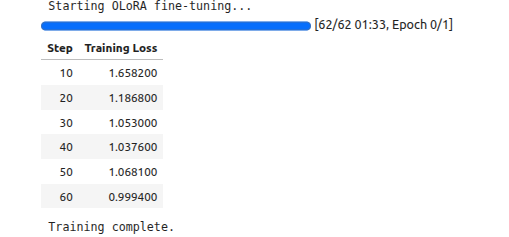


lora+=4

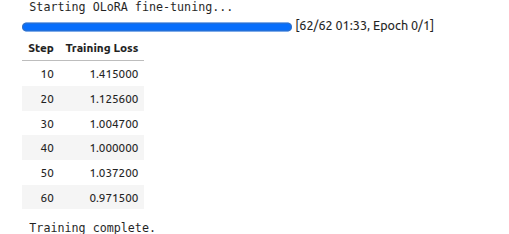



lora+=2

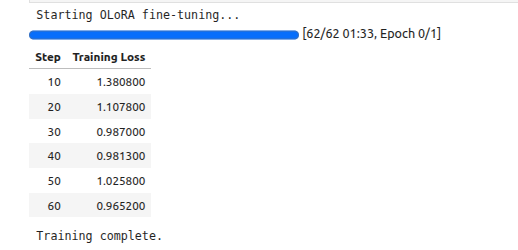

